In [1]:
from datetime import datetime, timedelta, time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pm4py
import os

c:\Users\nikla\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


### Question 1: Initial Overview

### Load data

In [2]:
# Load the event log
file_path = os.path.join(os.getcwd(), 'Event Logs', 'all.xes')
log = pm4py.read_xes(file_path)
df = pm4py.convert_to_dataframe(log)

c:\Users\nikla\anaconda3\Lib\site-packages\pm4py\utils.py:1000: UserWarning: Install the optional requirement `rustxes` to import/export files faster.
  warnings.warn(


parsing log, completed traces ::   0%|          | 0/1820 [00:00<?, ?it/s]

### (a)

In [3]:
# (a) Quick check of the basics
n_cases = df['case:concept:name'].nunique()
n_events = len(df)
n_activities = df['concept:name'].nunique()

# Timeframe Calculation
earliest_event = df['time:timestamp'].min()
latest_event = df['time:timestamp'].max()
total_timeframe = latest_event - earliest_event

print(f"--- General Statistics ---")
print(f"Number of Cases:      {n_cases}")
print(f"Number of Events:     {n_events}")
print(f"Unique Activities:    {n_activities}")
print(f"\n--- Timeframe ---")
print(f"Earliest Event:       {earliest_event}")
print(f"Latest Event:         {latest_event}")
print(f"Total Duration:       {total_timeframe}")

--- General Statistics ---
Number of Cases:      1820
Number of Events:     47553
Unique Activities:    26

--- Timeframe ---
Earliest Event:       2021-01-01 00:00:01+00:00
Latest Event:         2023-09-13 09:00:03+00:00
Total Duration:       985 days 09:00:02


### (b)

In [4]:
#number of variants
variants = pm4py.get_variants(df)
num_variants = len(variants)

# average events per case

avg_events_per_case = n_events / n_cases

print(f"Number of Variants: {num_variants}")
print("Average Events per Case:",round(avg_events_per_case,2),)


Number of Variants: 678
Average Events per Case: 26.13


### (c)

In [5]:
# (c) Attribute Analysis and Mapping

# Identify all columns
all_cols = df.columns

# Case attributes usually start with 'case:'
case_attrs = [col for col in all_cols if col.startswith('case:')]

# Event attributes are the rest, excluding the standard activity and timestamp columns
standard_cols = ['concept:name', 'time:timestamp', 'case:concept:name']
event_attrs = [col for col in all_cols if col not in case_attrs and col not in standard_cols]

print("### Case Attributes ###")
for attr in case_attrs:
    print(f"- {attr}")

print("\n### Event Attributes and their Activities ###")
for attr in event_attrs:
    # Get unique activities where this attribute is not null
    activities_with_attr = df[df[attr].notna()]['concept:name'].unique()
    
    # Format the output for readability
    act_list = ", ".join(activities_with_attr)
    print(f"Attribute: '{attr}'")
    print(f"  -> Found in activities: {act_list}\n")

### Case Attributes ###
- case:concept:name
- case:customer_id
- case:customer_name
- case:customer_ssid
- case:loan_amount
- case:case_creation_no

### Event Attributes and their Activities ###
Attribute: 'org:resource'
  -> Found in activities: Application Registered, Retrieve Identity Document, Retrieve Internal Log Data, Verify ID Automatically, Confirmed Identity, Query Central Bank System, Query Credit Bureau, Retrieve Customer Global Risk Score, Retrieve Financial Status, Reject Application, Send Rejection Notification, Create Assessment Report, Verify ID Manually, Decide Loan Application, Send Acceptance Confirmation, Accept Terms, Received Terms Acceptance, Transfer Funds, Start Repayments, Loan Default Notice Received, Formally Initiate Debt Recovery, Send to Collections, Installment Received, Request to Defer Payment Received, Accelerate Loan (Force Default), Repayment Completed

Attribute: 'lifecycle:transition'
  -> Found in activities: Application Registered, Retrieve Ide

### (d)

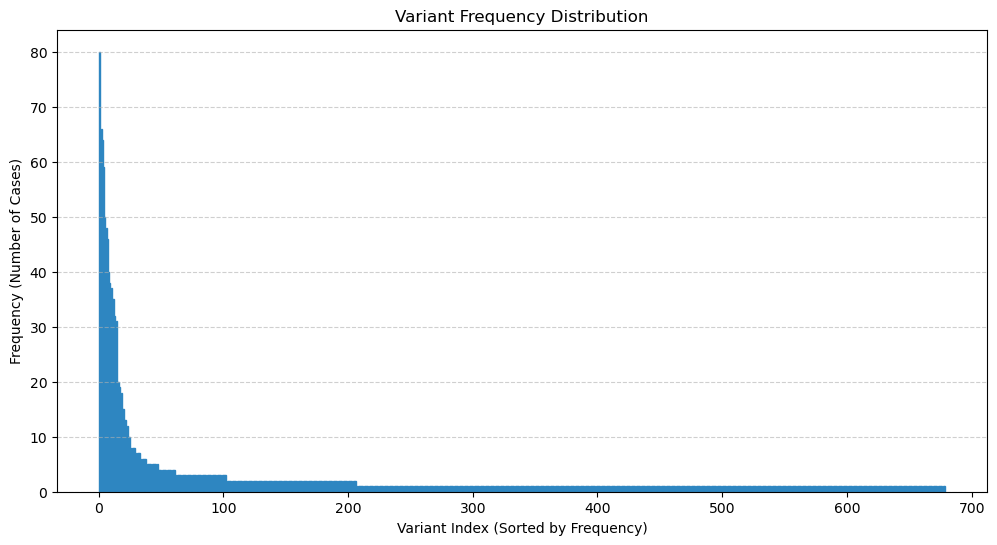

Total Cases: 1820
Total unique variants: 678
The most frequent variant covers 4.40% of all cases.


In [6]:
# 1. Get variants
variants = pm4py.get_variants(df)

# 2. Sort variants properly
# We check if the value is an integer (count) or a list (cases)
first_value = next(iter(variants.values()))

if isinstance(first_value, int):
    # If it's already a count, just use the value directly
    variants_sorted = sorted(variants.items(), key=lambda x: x[1], reverse=True)
    counts = [v[1] for v in variants_sorted]
else:
    # If it's a list of cases, take the length
    variants_sorted = sorted(variants.items(), key=lambda x: len(x[1]), reverse=True)
    counts = [len(v[1]) for v in variants_sorted]

# 3. Create the plot
variant_indices = range(1, len(counts) + 1)
plt.figure(figsize=(12, 6))
plt.bar(variant_indices, counts, color='#5DADE2', edgecolor='#2E86C1')
plt.xlabel('Variant Index (Sorted by Frequency)')
plt.ylabel('Frequency (Number of Cases)')
plt.title('Variant Frequency Distribution')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# 4. Stats for insights
total_cases = sum(counts)
top_variant_perc = (counts[0] / total_cases) * 100
print(f"Total Cases: {total_cases}")
print(f"Total unique variants: {len(counts)}")
print(f"The most frequent variant covers {top_variant_perc:.2f}% of all cases.")

### (e)

--- Case Duration Statistics (in Days) ---
Minimum           : 0.2542
Maximum           : 758.4361
Mean              : 292.0517
Median            : 220.8598
Standard Deviation: 220.7629


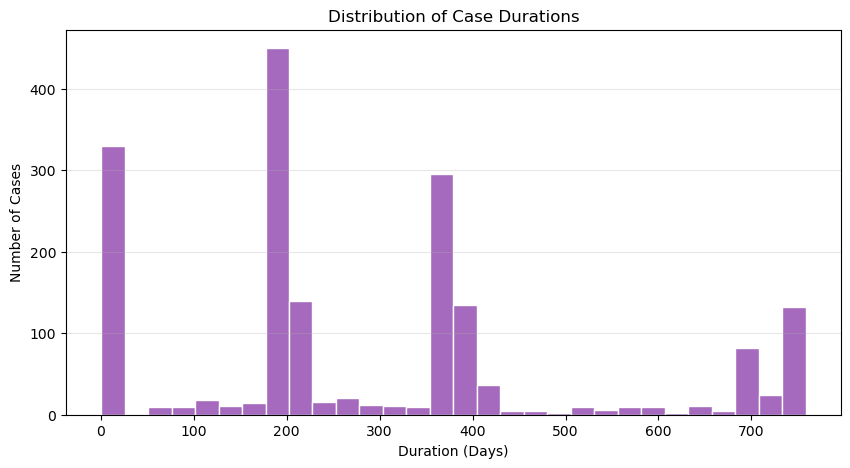

In [7]:
# 1. Calculate duration for each case
# We group by the case ID and find the difference between the max and min timestamp
case_durations = df.groupby('case:concept:name')['time:timestamp'].agg(lambda x: x.max() - x.min())

# 2. Convert durations to a numeric format (e.g., Days) for easier reporting
# Using total_seconds() / 86400 converts the timedeltas into a float representing days
durations_in_days = case_durations.dt.total_seconds() / 86400

# 3. Report Statistics
stats = {
    "Minimum": durations_in_days.min(),
    "Maximum": durations_in_days.max(),
    "Mean": durations_in_days.mean(),
    "Median": durations_in_days.median(),
    "Standard Deviation": durations_in_days.std()
}

print("--- Case Duration Statistics (in Days) ---")
for metric, value in stats.items():
    print(f"{metric:18}: {value:.4f}")

# 4. Optional: Quick histogram to visualize the distribution
plt.figure(figsize=(10, 5))
plt.hist(durations_in_days, bins=30, color='#A569BD', edgecolor='white')
plt.title('Distribution of Case Durations')
plt.xlabel('Duration (Days)')
plt.ylabel('Number of Cases')
plt.grid(axis='y', alpha=0.3)
plt.show()

### Question 2: General Visual Analytics & Exploration

### (a)

--- Top 5 Variants: Frequencies ---
Variant 1 (Frequency: 80 cases):
  Sequence: Application Registered -> Retrieve Identity Document -> Retrieve Internal Log Data -> Verify ID Automatically -> Confirmed Identity -> Query Central Bank System -> Query Credit Bureau -> Retrieve Customer Global Risk Score -> Retrieve Financial Status -> Create Assessment Report -> Decide Loan Application -> Send Acceptance Confirmation -> Accept Terms -> Received Terms Acceptance -> Transfer Funds -> Start Repayments -> Installment Received -> Installment Received -> Installment Received -> Installment Received -> Installment Received -> Installment Received -> Repayment Completed

Variant 2 (Frequency: 66 cases):
  Sequence: Application Registered -> Retrieve Identity Document -> Retrieve Internal Log Data -> Verify ID Automatically -> Confirmed Identity -> Query Central Bank System -> Retrieve Customer Global Risk Score -> Query Credit Bureau -> Retrieve Financial Status -> Create Assessment Report -> D

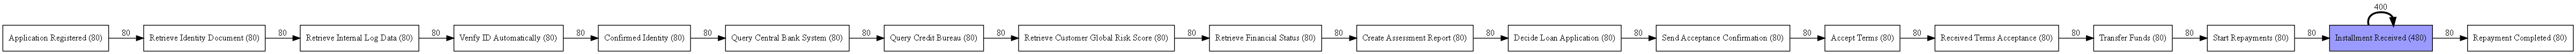


--- Comparison of the Five Variants ---


,Variant,Frequency,Length (Total Steps),Unique Activities,Active Attributes
0,V1,80,23,18,18
1,V2,66,23,18,18
2,V3,64,23,18,18
3,V4,59,23,18,18
4,V5,50,29,18,18


In [10]:
import os
import sys

# DYNAMIC PATH FIX: Automatically find the Graphviz executable for any user
current_env = sys.prefix
os.environ["PATH"] += os.pathsep + os.path.join(current_env, 'Library', 'bin', 'graphviz')
os.environ["PATH"] += os.pathsep + os.path.join(current_env, 'Library', 'bin')
os.environ["PATH"] += os.pathsep + os.path.join(current_env, 'bin') # For Mac/Linux compatibility


import pm4py
import pandas as pd
from IPython.display import Image, display



# 1. Select five variants and report their frequencies
variants = pm4py.get_variants(df)
variants_sorted = sorted(variants.items(), key=lambda x: x[1], reverse=True)
top_5 = variants_sorted[:5]

print("--- Top 5 Variants: Frequencies ---")
for i, (variant, count) in enumerate(top_5):
    print(f"Variant {i+1} (Frequency: {count} cases):")
    print(f"  Sequence: {' -> '.join(variant)}\n")


# BULLETPROOF PANDAS LOGIC: Map every case ID to its exact sequence
# This prevents pm4py.filter_variants from silently dropping data
case_sequences = df.groupby('case:concept:name')['concept:name'].apply(tuple)


# 2. Visualize Variant 1
print("--- Visualization of Variant 1 ---")
v1_sequence = top_5[0][0] # Keep as tuple for exact matching

# Extract only the Case IDs that perfectly match Variant 1
v1_case_ids = case_sequences[case_sequences == v1_sequence].index
df_v1 = df[df['case:concept:name'].isin(v1_case_ids)]

print(f"(Debug: Found {len(v1_case_ids)} cases and {len(df_v1)} events for Variant 1)\n")

# Using a Directly-Follows Graph (DFG)
dfg, start_activities, end_activities = pm4py.discover_dfg(df_v1)
from pm4py.visualization.dfg import visualizer as dfg_visualizer
gviz = dfg_visualizer.apply(dfg, log=df_v1, variant=dfg_visualizer.Variants.FREQUENCY, parameters={"format": "png"})
dfg_visualizer.save(gviz, "variant1.png")
display(Image(filename="variant1.png"))


# 3. Compare the five variants
print("\n--- Comparison of the Five Variants ---")
comparison_data = []

# Identify event attributes (excluding standard XES columns)
event_attrs = [col for col in df.columns if not col.startswith('case:') and col not in ['concept:name', 'time:timestamp']]

for i, (variant, count) in enumerate(top_5):
    # Use the bulletproof pandas filter for the comparison table as well
    v_case_ids = case_sequences[case_sequences == variant].index
    v_df = df[df['case:concept:name'].isin(v_case_ids)]
    
    # Check how many event attributes are actually populated
    active_attrs = [attr for attr in event_attrs if not v_df[attr].isnull().all()]
    
    comparison_data.append({
        "Variant": f"V{i+1}",
        "Frequency": count,
        "Length (Total Steps)": len(variant),
        "Unique Activities": len(set(variant)),
        "Active Attributes": len(active_attrs)
    })

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

### (b)

--- Discovering Frequency-Annotated DFG ---


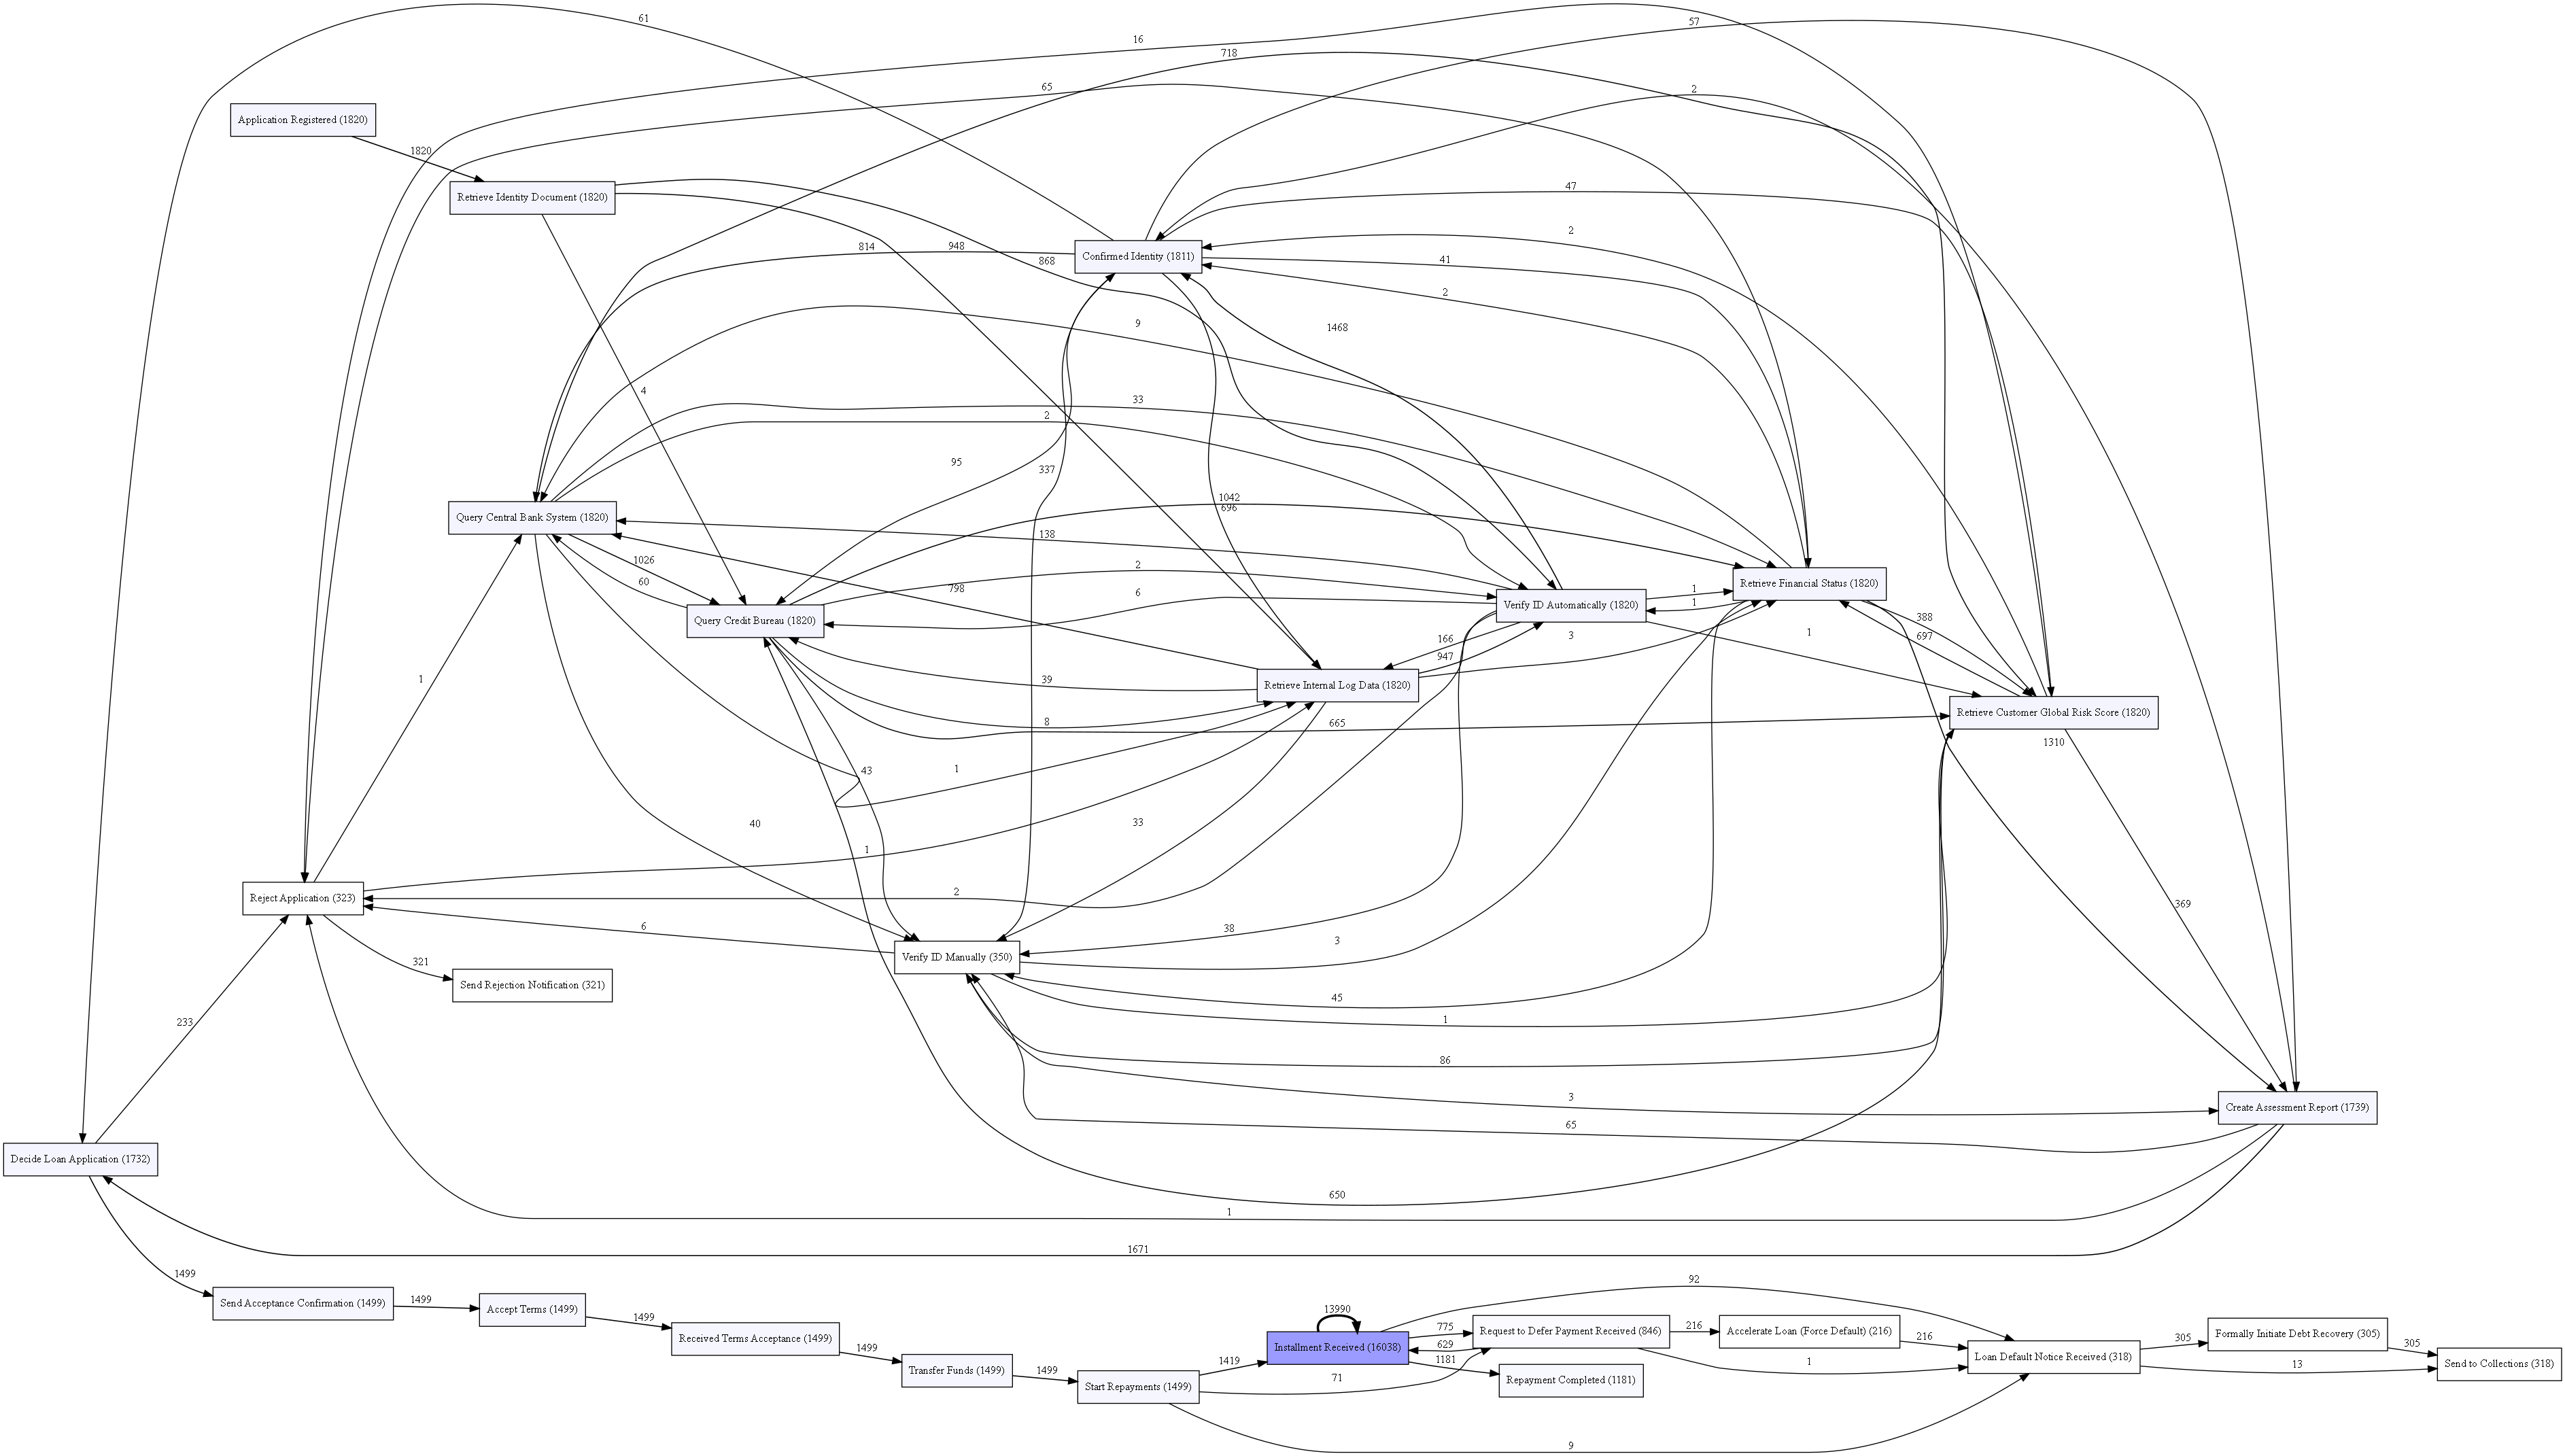

DFG successfully generated and saved as 'full_log_dfg.png'.


In [11]:
import pm4py
from pm4py.visualization.dfg import visualizer as dfg_visualizer
from IPython.display import Image, display

print("--- Discovering Frequency-Annotated DFG ---")

# 1. Discover the DFG from the entire event log (DataFrame)
# This returns the graph edges, start nodes, and end nodes
dfg, start_activities, end_activities = pm4py.discover_dfg(df)

# 2. Configure and generate the visualization
# We explicitly set the variant to FREQUENCY to satisfy the prompt requirement
gviz = dfg_visualizer.apply(
    dfg, 
    log=df, 
    variant=dfg_visualizer.Variants.FREQUENCY, 
    parameters={"format": "png"}
)

# 3. Save and display the output
dfg_visualizer.save(gviz, "full_log_dfg.png")
display(Image(filename="full_log_dfg.png"))

print("DFG successfully generated and saved as 'full_log_dfg.png'.")

### Question 3: Use Case-Specific Visual Analytics & Exploration

### (a)

In [14]:
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 47553 entries, 0 to 47552
Data columns (total 28 columns):
 #   Column                          Non-Null Count  Dtype              
---  ------                          --------------  -----              
 0   concept:name                    47553 non-null  str                
 1   time:timestamp                  47553 non-null  datetime64[us, UTC]
 2   org:resource                    47553 non-null  str                
 3   lifecycle:transition            47553 non-null  str                
 4   case:concept:name               47553 non-null  str                
 5   case:customer_id                47553 non-null  int64              
 6   case:customer_name              47553 non-null  str                
 7   case:customer_ssid              47553 non-null  str                
 8   case:loan_amount                47553 non-null  float64            
 9   case:case_creation_no           47553 non-null  int64              
 10  prior_defaults       

In [20]:
print("--- Searching for 'MID' ---")
found = False

for col in df.columns:
    # Check if 'MID' is in any row of this column (ignoring case just to be safe)
    if df[col].astype(str).str.contains('MID', case=False, na=False).any():
        print(f"✅ Found 'MID' in column: '{col}'")
        # Print the exact values it found so we know how it's formatted
        unique_matches = df[df[col].astype(str).str.contains('MID', case=False, na=False)][col].unique()
        print(f"   Exact values found: {unique_matches}\n")
        found = True

if not found:
    print("❌ Could not find 'MID' anywhere. Are you sure the file 'all.xes' contains these rejections?")

--- Searching for 'MID' ---
✅ Found 'MID' in column: 'code'
   Exact values found: <ArrowStringArray>
['MID']
Length: 1, dtype: str



In [21]:
#1. Identify cases that were rejected with the MID code
# : If 'MID' is an activity name, leave the next line as is.
# If 'MID' is in a different column (e.g., 'Reject_Reason'), change 'concept:name' to that column name!
mid_case_ids = df[df['code'] == 'MID']['case:concept:name'].unique()

# Filter the main dataframe to keep ONLY those cases
df_mid = df[df['case:concept:name'].isin(mid_case_ids)]

print(f"Total cases rejected due to MID: {len(mid_case_ids)}\n")

# 2. List all trace variants and their frequencies
variants_mid = pm4py.get_variants(df_mid)

# Sort by frequency (descending)
variants_sorted_mid = sorted(variants_mid.items(), key=lambda x: x[1], reverse=True)

print("--- MID Trace Variants & Frequencies ---")
for i, (variant, count) in enumerate(variants_sorted_mid):
    print(f"Variant {i+1} (Frequency: {count} cases):")
    print(f"  Sequence: {' -> '.join(variant)}\n")

Total cases rejected due to MID: 9

--- MID Trace Variants & Frequencies ---
Variant 1 (Frequency: 4 cases):
  Sequence: Application Registered -> Retrieve Identity Document -> Retrieve Internal Log Data -> Verify ID Automatically -> Query Central Bank System -> Query Credit Bureau -> Retrieve Customer Global Risk Score -> Retrieve Financial Status -> Create Assessment Report -> Verify ID Manually -> Reject Application -> Send Rejection Notification

Variant 2 (Frequency: 1 cases):
  Sequence: Application Registered -> Retrieve Identity Document -> Verify ID Automatically -> Retrieve Internal Log Data -> Query Central Bank System -> Query Credit Bureau -> Retrieve Financial Status -> Retrieve Customer Global Risk Score -> Create Assessment Report -> Verify ID Manually -> Reject Application -> Send Rejection Notification

Variant 3 (Frequency: 1 cases):
  Sequence: Application Registered -> Retrieve Identity Document -> Retrieve Internal Log Data -> Verify ID Automatically -> Reject App

In [ ]:
file_path = os.path.join(os.getcwd(), 'Event Logs', 'all.xes')
logobject = pm4py.convert_to_event_log(file_path)
logobject

In [ ]:
# 1. Load the specific LCS event log
file_path_lcs = os.path.join(os.getcwd(), 'Event Logs', 'lcs-rejected-customers.xes')
file_path_lcs = 'lcs-rejected-customers.xes' # Update this path if it's in a folder like 'Event/lcs-rejected-customers.xes'
log_lcs = pm4py.read_xes(file_path_lcs)
df_lcs = pm4py.convert_to_dataframe(log_lcs)

# 2. Group the data by case
case_groups = df_lcs.groupby('case:concept:name')

cases_after_decide = []
cases_without_decide = []

for case_id, group in case_groups:
    activities = group['concept:name'].tolist()
    
    # Check if this specific case was rejected with the LCS code
    is_lcs_rejected = (group['code'] == 'LCS').any()
    
    if is_lcs_rejected:
        # Isolate the specific risk score event
        risk_event = group[group['concept:name'] == 'Retrieve Customer Global Risk Score']
        
        # Clean up the output so we can easily spot the score value
        if not risk_event.empty:
            risk_data = risk_event.dropna(axis=1).iloc[0].to_dict()
            # Filter out standard PM4Py columns to leave just the custom attributes (like the score)
            score_info = {k: v for k, v in risk_data.items() if not k.startswith('case:') and k not in ['concept:name', 'time:timestamp', 'code']}
        else:
            score_info = "No risk score event found"

        # Categorize based on the presence of 'Decide Loan Application'
        if 'Decide Loan Application' in activities:
            cases_after_decide.append((case_id, score_info))
        else:
            cases_without_decide.append((case_id, score_info))

# 3. Print exactly 2 of each for the assignment
print("--- 2 Cases Rejected (LCS) AFTER 'Decide Loan Application' ---")
for case_id, score in cases_after_decide[:2]:
    print(f"Case ID: {case_id}")
    print(f"Risk Score Attributes: {score}\n")

print("--- 2 Cases Rejected (LCS) WITHOUT 'Decide Loan Application' ---")
for case_id, score in cases_without_decide[:2]:
    print(f"Case ID: {case_id}")
    print(f"Risk Score Attributes: {score}\n")

### Question 4: Process Discovery

### Question 5: Conformance Checking